# Classification with PyTorch v3 (oracle) — Response, 3/3-only ablation

**Version:** 3rd Version (feature ablation). **Role:** reference oracle for the v3 scratch twin.
Identical to v2 (deeper ResNet MLP, 100 epochs, cosine + wd) except features: **3/3 consensus only (10 cols, all numeric → 10 dims, no one-hot)**. Tests whether the 2/3 tier helped or added noise. Weights → `./weights_v3/`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("weights_v3", exist_ok=True)
print("torch:", torch.__version__)

# ---- 1. LOAD DATA (identical cleaning; 3/3 features only, no categoricals) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
print("cleaned:", df.shape, "| Response rate:", round(df["Response"].mean(), 4))

# 3/3 consensus only (dropped 2/3: AcceptedCmp1/2, Marital_Status, NumWebPurchases,
# MntSweet/FishProducts, NumStorePurchases, Age)
CLF_3OF3 = [
    "AcceptedCmp5", "AcceptedCmp3", "MntWines", "MntMeatProducts",
    "NumCatalogPurchases", "Recency", "Customer_Tenure_Days", "MntGoldProds",
    "Income", "MntFruits",
]
X_full = df[CLF_3OF3].copy()
FEATURE_COLS = list(X_full.columns)
y_full = df["Response"].astype(float).values
print(f"features: {len(FEATURE_COLS)} dims, all numeric (no one-hot needed)")

torch: 2.14.1
cleaned: (2237, 28) | Response rate: 0.1493
features: 10 dims, all numeric (no one-hot needed)


## 2–3. Dataset Class + DataLoader (same 80/20 stratified split + scaler logic as v2)

In [2]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32)).view(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full.values, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
inc_idx = FEATURE_COLS.index("Income")
train_median = np.nanmedian(X_temp[:, inc_idx])
for arr in (X_temp, X_test):
    arr[:, inc_idx] = np.where(np.isnan(arr[:, inc_idx]), train_median, arr[:, inc_idx])
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
print(f"train {Xtr.shape} test {Xte.shape} | test pos rate {y_test.mean():.3f} | median fill {train_median:.0f}")
train_ds, test_ds = TabularDataset(Xtr, y_temp), TabularDataset(Xte, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                            generator=torch.Generator().manual_seed(SEED))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

train (1789, 10) test (448, 10) | test pos rate 0.150 | median fill 51533


## 4. Model Class v3 — same ResNet block as v2, in_dim=10

In [3]:
class ClfDeepMLP(nn.Module):
    def __init__(self, in_dim=10, h=64, p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h)
        self.bn1 = nn.BatchNorm1d(h)
        self.fc2 = nn.Linear(h, h)
        self.bn2 = nn.BatchNorm1d(h)
        self.fc3 = nn.Linear(h, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(p)
        for fc, nl in ((self.fc1, "relu"), (self.fc2, "relu"), (self.fc3, "linear")):
            nn.init.kaiming_normal_(fc.weight, nonlinearity=nl)
            nn.init.zeros_(fc.bias)
    def forward(self, x):
        d1 = self.drop(self.relu(self.bn1(self.fc1(x))))
        s = self.bn2(self.fc2(d1)) + d1
        d2 = self.drop(self.relu(s))
        return self.fc3(d2)

device = torch.device("cpu")
model = ClfDeepMLP(in_dim=len(FEATURE_COLS)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"params: {n_params} (expect ~5185)")
pos = (y_temp == 1).sum(); neg = (y_temp == 0).sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg / pos]))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
print(f"pos_weight: {neg / pos:.3f} | epochs 100 | cosine schedule | wd 1e-4")

ClfDeepMLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.2, inplace=False)
)
params: 5185 (expect ~5185)


pos_weight: 5.700 | epochs 100 | cosine schedule | wd 1e-4


## 5. Training Loop v3 (100 epochs) — saves to weights_v3

epoch 001 | train 0.7108 | val 0.7042 | acc 0.6719 | F1 0.4096 | lr 1.00e-03


epoch 010 | train 0.4665 | val 0.4811 | acc 0.7388 | F1 0.4608 | lr 9.76e-04


epoch 020 | train 0.4629 | val 0.4888 | acc 0.7076 | F1 0.4378 | lr 9.05e-04


epoch 030 | train 0.4535 | val 0.4811 | acc 0.7165 | F1 0.4502 | lr 7.94e-04


epoch 040 | train 0.4574 | val 0.4864 | acc 0.7165 | F1 0.4549 | lr 6.55e-04


...

epoch 060 | train 0.4188 | val 0.4558 | acc 0.7388 | F1 0.4658 | lr 3.45e-04


epoch 070 | train 0.4400 | val 0.4749 | acc 0.7210 | F1 0.4541 | lr 2.06e-04


epoch 080 | train 0.4244 | val 0.4598 | acc 0.7388 | F1 0.4706 | lr 9.55e-05


epoch 090 | train 0.4229 | val 0.4601 | acc 0.7388 | F1 0.4706 | lr 2.45e-05


epoch 100 | train 0.4211 | val 0.4589 | acc 0.7388 | F1 0.4706 | lr 0.00e+00
saved to weights_v3/


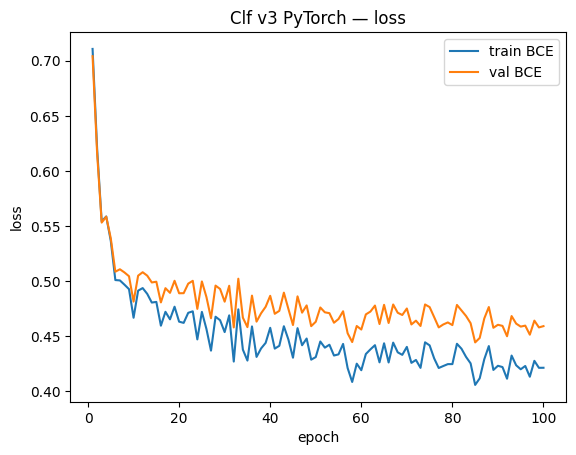

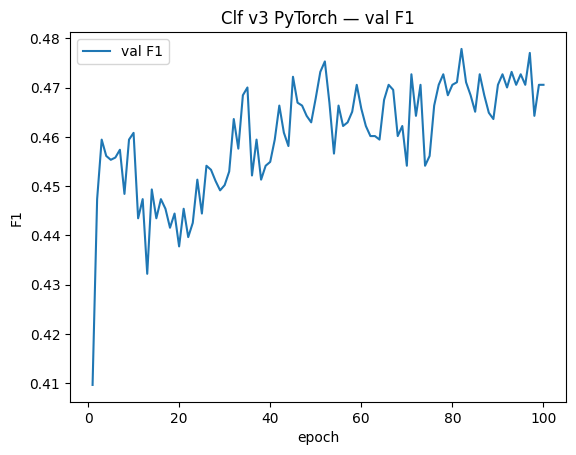

In [4]:
EPOCHS = 100
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}
bce = nn.BCEWithLogitsLoss()

def evaluate(m):
    m.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
        yt = torch.from_numpy(y_test.astype(np.float32)).view(-1, 1).to(device)
        logits = m(Xt)
        loss = bce(logits, yt).item()
        prob = torch.sigmoid(logits).cpu().numpy().ravel()
        pred = (prob >= 0.5).astype(int)
        return loss, accuracy_score(y_test, pred), f1_score(y_test, pred)

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()
    model.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xtr.astype(np.float32)).to(device)
        yt = torch.from_numpy(y_temp.astype(np.float32)).view(-1, 1).to(device)
        tr = bce(model(Xt), yt).item()
    vl, va, vf = evaluate(model)
    lr = optimizer.param_groups[0]["lr"]
    history["epoch"].append(epoch)
    history["train_loss"].append(tr)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf)
    history["lr"].append(lr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:03d} | train {tr:.4f} | val {vl:.4f} | acc {va:.4f} | F1 {vf:.4f} | lr {lr:.2e}")

torch.save(model.state_dict(), "weights_v3/classification_mlp.pt")
np.savez("weights_v3/classification_scaler.npz", mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(FEATURE_COLS), train_median=np.array([train_median]))
pd.DataFrame(history).to_csv("weights_v3/classification_pytorch_history.csv", index=False)
print("saved to weights_v3/")
plt.figure(); plt.plot(history["epoch"], history["train_loss"], label="train BCE")
plt.plot(history["epoch"], history["val_loss"], label="val BCE")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Clf v3 PyTorch — loss"); plt.show()
plt.figure(); plt.plot(history["epoch"], history["val_f1"], label="val F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.legend(); plt.title("Clf v3 PyTorch — val F1"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights_v3/classification_mlp.pt`

In [5]:
fresh = ClfDeepMLP(in_dim=len(FEATURE_COLS)).to(device)
fresh.load_state_dict(torch.load("weights_v3/classification_mlp.pt", map_location=device))
fresh.eval()
with torch.no_grad():
    Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
    prob = torch.sigmoid(fresh(Xt)).cpu().numpy().ravel()
pred = (prob >= 0.5).astype(int)
test_bce = float(bce(fresh(Xt), torch.from_numpy(y_test.astype(np.float32)).view(-1,1).to(device)).item())
metrics = {
    "test_loss_BCE": round(test_bce, 4),
    "accuracy": round(float(accuracy_score(y_test, pred)), 4),
    "precision": round(float(precision_score(y_test, pred, zero_division=0)), 4),
    "recall": round(float(recall_score(y_test, pred, zero_division=0)), 4),
    "f1": round(float(f1_score(y_test, pred, zero_division=0)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, prob)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights_v3/classification_pytorch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  prob={prob[i]:.3f} pred={pred[i]} true={int(y_test[i])}")

{
  "test_loss_BCE": 0.4589,
  "accuracy": 0.7388,
  "precision": 0.3377,
  "recall": 0.7761,
  "f1": 0.4706,
  "roc_auc": 0.8466,
  "n_test": 448,
  "seed": 42
}
  prob=0.032 pred=0 true=0
  prob=0.000 pred=0 true=0
  prob=0.028 pred=0 true=0
  prob=0.088 pred=0 true=0
  prob=0.029 pred=0 true=0
